In [1]:
import numpy as np
import json
import torch
from torchsummary import summary
from tqdm import tqdm
from pathlib import Path

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


In [3]:
from src.models.base_model import base_model
from src.utils.metrics import AverageMeter, CombinedLoss, DiceLoss, dice_coefficient, iou_score, pixel_accuracy

Пути к каталогам.

In [4]:
config_dir = Path("./src/config/")
model_name = 'base-model'

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

model_config_path = config_dir / f"{model_name}-config.json"
assert model_config_path.exists(), f"Config not found: {model_config_path}"
with open(model_config_path, "r") as f:
    model_config = json.load(f)

dataset_config_path = config_dir / f"{model_config['dataset_name']}-config.json"
assert dataset_config_path.exists(), f"Config not found: {dataset_config_path}"
with open(dataset_config_path, "r") as f:
    dataset_config = json.load(f)
    
data_path = Path(general_config['data_dir']) / dataset_config['dataset_name']
checkpoints_dir = Path(general_config['checkpoints_dir'])

In [5]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

# Тест архитектуры

In [6]:
mdl_input_size = model_config['input_size']

model = base_model(
    in_channels = mdl_input_size[0],
    out_channels = 4,
    features = model_config['feature_list'],
    #device = self.device
    )
model = model.to(device)
model.eval()

test_input = torch.randn(1, *mdl_input_size).to(device)
test_output = model(test_input)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size}")
print(f"  Input:  {test_input.shape}")
print(f"  Output: {test_output.shape}")
summary(model, tuple(mdl_input_size))

Encoder features by level: [32, 64, 128, 256]
Model size: 1397864
  Input:  torch.Size([1, 2, 512])
  Output: torch.Size([1, 4, 512])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
    InstanceNorm1d-1               [-1, 2, 512]               4
            Conv1d-2              [-1, 32, 512]             224
       BatchNorm1d-3              [-1, 32, 512]              64
              ReLU-4              [-1, 32, 512]               0
          baseConv-5              [-1, 32, 512]               0
         MaxPool1d-6              [-1, 32, 256]               0
            Conv1d-7              [-1, 64, 256]           6,208
       BatchNorm1d-8              [-1, 64, 256]             128
              ReLU-9              [-1, 64, 256]               0
         baseConv-10              [-1, 64, 256]               0
        MaxPool1d-11              [-1, 64, 128]               0
           Conv1d-12             

In [7]:
test_output

tensor([[[-0.0950,  0.0563,  0.0972,  ..., -0.0187, -0.0370, -0.0754],
         [-0.1167, -0.1093, -0.1685,  ..., -0.2006, -0.1524, -0.1538],
         [ 0.0909,  0.0158, -0.0027,  ...,  0.1543,  0.0770,  0.1033],
         [-0.0748, -0.0696, -0.0030,  ...,  0.0485, -0.1224, -0.0317]]],
       grad_fn=<ConvolutionBackward0>)

## dataloader

In [8]:
SEED = np.random.randint(0, 10000)
torch.manual_seed(SEED)
np.random.seed(SEED)

In [9]:
from src.dataloaders.ZerosPolesDataset import TransformsConfig, ZerosPolesDataset
from torch.utils.data import DataLoader
# Setting seeds.
def worker_init_fn(worker_id):
    np.random.seed(torch.initial_seed() % 2 ** 32)
    
train_transforms = TransformsConfig(
    #crop_ratio=[1.0, 1.0],
    time_delay=[0.0, 1e-9],
    noise_level=[5e-3, 30e-3],
    noise_reduce=2,
    gain=[0.9, 1.1]
)
val_transforms = None

train_loader = DataLoader(
    ZerosPolesDataset(
        dataset_dir = Path(general_config['data_dir']) / dataset_config['dataset_name'],
        split = 'train',
        transforms=train_transforms
        ),
    batch_size=model_config["batch_size"],
    shuffle=True,
    num_workers=0,#model_config["workers"],
    worker_init_fn=worker_init_fn,
    pin_memory=True)

val_loader = DataLoader(
    ZerosPolesDataset(
        dataset_dir = Path(general_config['data_dir']) / dataset_config['dataset_name'],
        split = 'val',
        transforms=val_transforms
        ),
    batch_size=model_config["batch_size"],
    shuffle=False,
    num_workers=model_config["workers"],
    pin_memory=True)

In [10]:
checkpoints_file = checkpoints_dir / f"best_{model_name}.pth"
assert checkpoints_file.exists(), f"Checkpoints not found: {checkpoints_file}"

from src.models.model_utilizer import load_net

model, epoch, _, _ = load_net(
                net=model,
                checkpoints_file=checkpoints_file,
                device=device
        )

model.eval()

Restoring checkpoint:  checkpoints\best_base-model.pth


_base_model(
  (input_norm): InstanceNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (encoder_blocks): ModuleList(
    (0): baseConv(
      (base_conv): Sequential(
        (0): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): baseConv(
      (base_conv): Sequential(
        (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): baseConv(
      (base_conv): Sequential(
        (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): baseConv(
      (base_conv): Sequential(
        (0): Conv1d

In [26]:
import matplotlib.pyplot as plt
import random
def visualize_predictions(
    model,
    dataloader,
    threshold,
    device,
    num_samples
    ):
    
    inputs, masks, _ = next(iter(dataloader))
    
    with torch.no_grad():
        logits = model(inputs.to(device))
        outputs = torch.sigmoid(logits)
        predictions = (outputs.detach() > threshold).float()
    
        masks = masks.cpu()
        predictions = predictions.cpu()
    
    _, axes = plt.subplots(num_samples, 2, figsize=(15, 2*num_samples))#, constrained_layout=True)
    random_idx = random.randrange(0, len(masks))
    
    random_idx = random.sample(range(len(masks)), num_samples)
    for i, sample_idx in enumerate(random_idx):
        #.permute(1, 2, 0)
        mask_true = masks[sample_idx, :].squeeze(0).numpy() 
        mask_pred = predictions[sample_idx, :].squeeze(0).numpy()
        
        #dice = dice_coefficient(logits[i].cpu(), masks[i])
        #iou = iou_score(logits[i].cpu(), masks[i])
        
        
        axes[i, 0].imshow(mask_pred, cmap='gray', aspect='auto', interpolation='nearest')
        axes[i, 0].set_title('Predictions', fontsize=12)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_true, cmap='gray', aspect='auto', interpolation='nearest')
        axes[i, 1].set_title('Ground truth', fontsize=12)
        axes[i, 1].axis('off') 

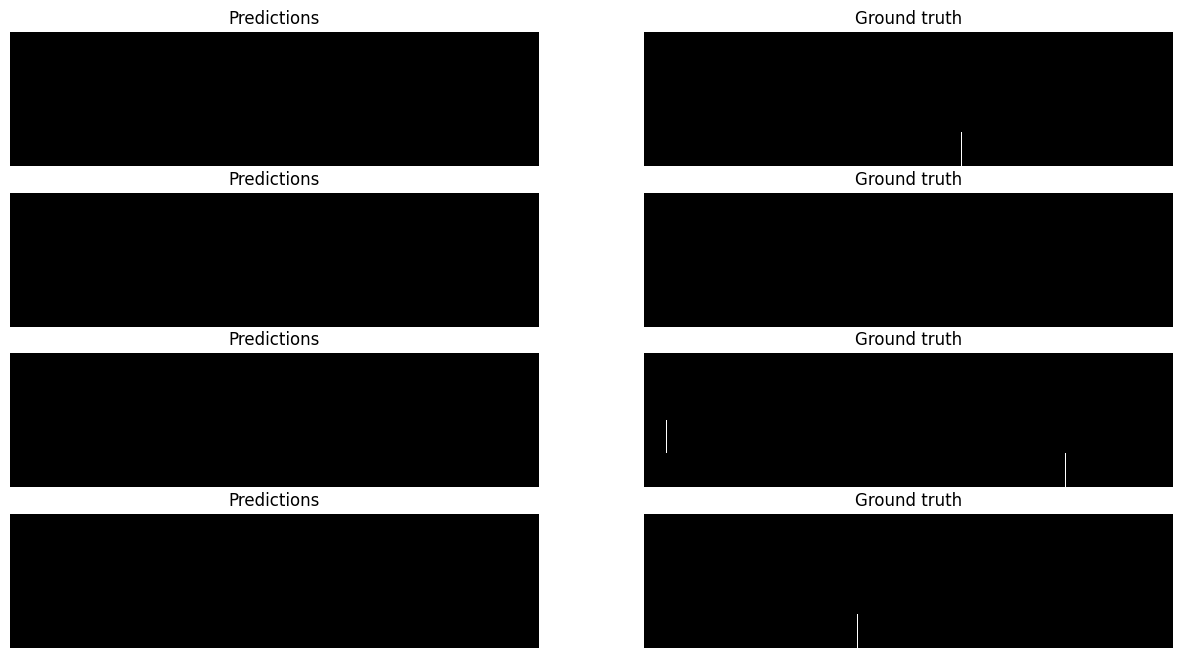

In [27]:
visualize_predictions(
        model=model,
        dataloader=val_loader,
        threshold=0.0,
        device=device,
        num_samples=4
        )

In [ ]:
# 1. Initialize accumulators (use float64 for numerical stability)
channel_sum = None
channel_sum_sq = None
total_samples = 0  # Total number of scalar values per channel

# 2. Iterate over dataset
with torch.no_grad():
    for data_tuple in tqdm(val_loader, desc="Calculating Stats"):
        inputs = data_tuple[0].to(device)
        
        inputs = inputs.float()
        B, C, L = inputs.shape  # [Batch, Channels, Length]
        
        # Initialize on first batch (handles dynamic channel count)
        if channel_sum is None:
            channel_sum = torch.zeros(C, dtype=torch.float64, device=device)
            channel_sum_sq = torch.zeros(C, dtype=torch.float64, device=device)
        
        # 3. Accumulate sum and sum of squares per channel
        # Sum over Batch (0) and Length (2), keep Channel (1)
        channel_sum += inputs.sum(dim=(0, 2)).double()
        channel_sum_sq += (inputs ** 2).sum(dim=(0, 2)).double()
        
        # Count total samples per channel: Batch * Length
        total_samples += B * L

# 4. Compute Final Mean and Std
mean = channel_sum / total_samples
# Variance = E[X²] - (E[X])²
var = (channel_sum_sq / total_samples) - (mean ** 2)

mean = mean.cpu()
std = torch.sqrt(var).cpu()

print(f"Mean: {mean.numpy()}")
print(f"Std:  {std.numpy()}")

Calculating Stats: 100%|██████████| 20/20 [00:07<00:00,  2.58it/s]

Mean: [529.12203564 496.96538726]
Std:  [11079.7596183  11102.14110049]


## Run 1:
- Mean: [ 984.91466768 2397.26128974]
- Std:  [ 55818.49198814 218841.79374928]

## Run 2:
- Mean: [1001.5774273 2397.346644 ]
- Std:  [ 57678.93105483 218281.70283202]

## Run 3:
- Mean: [1014.77855625 2394.29139941]
- Std:  [ 59264.07932032 217862.15627679]

In [ ]:
with torch.no_grad():
    
    inputs, masks, _ = next(iter(val_loader))
    inputs, masks = inputs.to(device), masks.to(device)
    
    outputs = model(inputs)
        
    print(dice_coefficient(outputs.detach(), masks.detach()))
    print(iou_score(outputs.detach(), masks.detach()))
    
    '''
    for data_tuple in tqdm(val_loader, desc="Val"):
        
        inputs, masks = data_tuple[0].to(device), data_tuple[1].to(device)
        
        outputs = model(inputs)
        
        print(dice_coefficient(outputs.detach(), masks.detach()))
        print(iou_score(outputs.detach(), masks.detach()))
    '''

d:\git\ITMO\frequency-response-encoder\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.0008542835712432861
0.000428000814281404
